# 07. CortexODE Stats Evaluation

Compare the recomputed ScaleSurfer FreeSurfer-tail statistics in `data/subjects_dir/*/stats` against the corresponding FreeSurfer 8 cache entries in `data/fs8_freesurfer_stats_cache/*/stats`.

The notebook is intentionally stats-only: it discovers paired subject directories, parses FreeSurfer `.stats` files, builds correlation tables, and writes scatter plots to `docs/notebooks/02_surface/07_cortex_ode_figures/`.
        


In [1]:
from __future__ import annotations

import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats as scipy_stats

from scalesurfer.config import MODULE_PATH

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 40)



In [2]:
BASE_PATH = MODULE_PATH.parent
PRED_STATS_ROOT = BASE_PATH / "data" / "subjects_dir"
GT_STATS_CACHE = BASE_PATH / "data" / "fs8_freesurfer_stats_cache"
FIG_DIR = BASE_PATH / "docs" / "notebooks" / "02_surface" / "07_cortex_ode_figures"
SUMMARY_CSV = FIG_DIR / "metric_summary.csv"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_STATS = (
    "aseg.stats",
    "wmparc.stats",
    "aparc+aseg.stats",
    "lh.aparc.stats",
    "rh.aparc.stats",
    "lh.aparc.pial.stats",
    "rh.aparc.pial.stats",
)
VOLUME_STATS_FILES = ("aseg.stats", "wmparc.stats", "aparc+aseg.stats")
SURFACE_STATS_FILES = (
    "lh.aparc.stats",
    "rh.aparc.stats",
    "lh.aparc.pial.stats",
    "rh.aparc.pial.stats",
)

print(f"Predicted stats root : {PRED_STATS_ROOT}")
print(f"GT stats cache       : {GT_STATS_CACHE}")
print(f"Figure output dir    : {FIG_DIR}")
print(f"Metric summary CSV   : {SUMMARY_CSV}")



Predicted stats root : /home/rph/scalesurfer/data/subjects_dir
GT stats cache       : /home/rph/scalesurfer/data/fs8_freesurfer_stats_cache
Figure output dir    : /home/rph/scalesurfer/docs/notebooks/02_surface/07_cortex_ode_figures
Metric summary CSV   : /home/rph/scalesurfer/docs/notebooks/02_surface/07_cortex_ode_figures/metric_summary.csv


## 1. Pair Predicted Subjects With FS8 Cache Entries


In [3]:
def find_gt_subject_dir(subject_id: str) -> Path | None:
    exact = GT_STATS_CACHE / subject_id
    if (exact / "stats").is_dir():
        return exact
    matches = sorted(p for p in GT_STATS_CACHE.glob(f"{subject_id}__*") if (p / "stats").is_dir())
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise RuntimeError(f"Ambiguous GT matches for {subject_id}: {matches[:5]}")
    return None


def missing_stats(stats_dir: Path) -> tuple[str, ...]:
    return tuple(name for name in REQUIRED_STATS if not (stats_dir / name).exists())

records = []
for pred_dir in sorted(p for p in PRED_STATS_ROOT.iterdir() if p.is_dir() and (p / "stats").is_dir()):
    subject_id = pred_dir.name
    gt_dir = find_gt_subject_dir(subject_id)
    records.append(
        {
            "subject_id": subject_id,
            "pred_dir": pred_dir,
            "gt_dir": gt_dir,
            "missing_pred_stats": missing_stats(pred_dir / "stats"),
            "missing_gt_stats": missing_stats(gt_dir / "stats") if gt_dir is not None else REQUIRED_STATS,
        }
    )

paired_df = pd.DataFrame(records)
if paired_df.empty:
    raise RuntimeError(f"No predicted stats directories found under {PRED_STATS_ROOT}")

complete_pairs = paired_df[
    paired_df["gt_dir"].notna()
    & paired_df["missing_pred_stats"].map(len).eq(0)
    & paired_df["missing_gt_stats"].map(len).eq(0)
].copy()

print(f"Predicted subjects with stats : {len(paired_df)}")
print(f"Complete GT/pred pairs        : {len(complete_pairs)}")

incomplete = paired_df.drop(complete_pairs.index)
if not incomplete.empty:
    display(incomplete[["subject_id", "gt_dir", "missing_pred_stats", "missing_gt_stats"]])

if complete_pairs.empty:
    raise RuntimeError("No complete GT/pred stats pairs were found.")

display(complete_pairs[["subject_id", "pred_dir", "gt_dir"]].head(12))



Predicted subjects with stats : 48
Complete GT/pred pairs        : 48


,subject_id,pred_dir,gt_dir
0,ds000053,/home/rph/scalesurfer/data/subjects_dir/ds000053,/home/rph/scalesurfer/data/fs8_freesurfer_stat...
1,ds000205,/home/rph/scalesurfer/data/subjects_dir/ds000205,/home/rph/scalesurfer/data/fs8_freesurfer_stat...
2,ds001131,/home/rph/scalesurfer/data/subjects_dir/ds001131,/home/rph/scalesurfer/data/fs8_freesurfer_stat...
3,ds001241,/home/rph/scalesurfer/data/subjects_dir/ds001241,/home/rph/scalesurfer/data/fs8_freesurfer_stat...
4,ds001563,/home/rph/scalesurfer/data/subjects_dir/ds001563,/home/rph/scalesurfer/data/fs8_freesurfer_stat...
5,ds001839,/home/rph/scalesurfer/data/subjects_dir/ds001839,/home/rph/scalesurfer/data/fs8_freesurfer_stat...
6,ds002168,/home/rph/scalesurfer/data/subjects_dir/ds002168,/home/rph/scalesurfer/data/fs8_freesurfer_stat...
7,ds002655,/home/rph/scalesurfer/data/subjects_dir/ds002655,/home/rph/scalesurfer/data/fs8_freesurfer_stat...
8,ds002687,/home/rph/scalesurfer/data/subjects_dir/ds002687,/home/rph/scalesurfer/data/fs8_freesurfer_stat...
9,ds002750,/home/rph/scalesurfer/data/subjects_dir/ds002750,/home/rph/scalesurfer/data/fs8_freesurfer_stat...


## 2. Parse FreeSurfer Stats Files


In [4]:
TABLE_COL_RE = re.compile(r"^# TableCol\s+(\d+)\s+ColHeader\s+(.+?)\s*$")


def as_float(value) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return float("nan")


def parse_measure_lines(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text(errors="replace").splitlines():
        if not line.startswith("# Measure "):
            continue
        parts = [part.strip() for part in line[len("# Measure ") :].split(",")]
        value_idx = None
        value = float("nan")
        for idx in range(len(parts) - 1, -1, -1):
            value = as_float(parts[idx])
            if np.isfinite(value):
                value_idx = idx
                break
        if value_idx is None:
            continue
        rows.append(
            {
                "scope": parts[0] if len(parts) > 0 else "",
                "metric": parts[1] if len(parts) > 1 else parts[0],
                "description": parts[2] if len(parts) > 2 else "",
                "value": value,
                "units": parts[value_idx + 1] if value_idx + 1 < len(parts) else "",
            }
        )
    return pd.DataFrame(rows)


def parse_stats_table(path: Path) -> pd.DataFrame:
    headers = {}
    data_lines = []
    for line in path.read_text(errors="replace").splitlines():
        match = TABLE_COL_RE.match(line)
        if match:
            headers[int(match.group(1))] = match.group(2).strip()
            continue
        if line and not line.startswith("#"):
            data_lines.append(line.split())

    if not headers or not data_lines:
        return pd.DataFrame()

    columns = [headers[idx] for idx in sorted(headers)]
    rows = [parts[: len(columns)] for parts in data_lines if len(parts) >= len(columns)]
    df = pd.DataFrame(rows, columns=columns)

    for col in df.columns:
        if col == "StructName":
            continue
        converted = pd.to_numeric(df[col], errors="coerce")
        if converted.notna().any():
            df[col] = converted
    return df


def surface_parts(stats_file: str) -> tuple[str, str]:
    hemi = stats_file.split(".")[0]
    surface = "pial" if ".pial." in stats_file else "white"
    return hemi, surface


DK_STRUCTURES = {
    "bankssts", "caudalanteriorcingulate", "caudalmiddlefrontal", "cuneus",
    "entorhinal", "fusiform", "inferiorparietal", "inferiortemporal",
    "isthmuscingulate", "lateraloccipital", "lateralorbitofrontal", "lingual",
    "medialorbitofrontal", "middletemporal", "parahippocampal", "paracentral",
    "parsopercularis", "parsorbitalis", "parstriangularis", "pericalcarine",
    "postcentral", "posteriorcingulate", "precentral", "precuneus",
    "rostralanteriorcingulate", "rostralmiddlefrontal", "superiorfrontal",
    "superiorparietal", "superiortemporal", "supramarginal", "frontalpole",
    "temporalpole", "transversetemporal", "insula",
}


def normalize_surface_structure(name: str) -> str:
    name = str(name)
    for prefix in ("ctx-lh-", "ctx-rh-"):
        if name.startswith(prefix):
            return name[len(prefix) :]
    return name



## 3. Collect Comparable Measurements


In [5]:
volume_rows = []
header_rows = []
roi_rows = []

for row in complete_pairs.itertuples(index=False):
    subject_id = row.subject_id
    pred_stats = Path(row.pred_dir) / "stats"
    gt_stats = Path(row.gt_dir) / "stats"

    for stats_file in VOLUME_STATS_FILES:
        gt_table = parse_stats_table(gt_stats / stats_file)
        pred_table = parse_stats_table(pred_stats / stats_file)
        if gt_table.empty or pred_table.empty or "Volume_mm3" not in gt_table or "Volume_mm3" not in pred_table:
            continue
        if "SegId" not in gt_table or "SegId" not in pred_table:
            continue

        gt_keep = gt_table[["SegId", "StructName", "Volume_mm3"]].rename(
            columns={"StructName": "gt_struct", "Volume_mm3": "gt_value"}
        )
        pred_keep = pred_table[["SegId", "StructName", "Volume_mm3"]].rename(
            columns={"StructName": "pred_struct", "Volume_mm3": "pred_value"}
        )
        merged = gt_keep.merge(pred_keep, on="SegId", how="inner")
        for item in merged.itertuples(index=False):
            volume_rows.append(
                {
                    "subject_id": subject_id,
                    "stats_file": stats_file,
                    "metric": "Volume_mm3",
                    "seg_id": int(item.SegId),
                    "structure": item.gt_struct,
                    "gt_value": float(item.gt_value),
                    "pred_value": float(item.pred_value),
                }
            )

    for stats_file in SURFACE_STATS_FILES:
        hemi, surface = surface_parts(stats_file)
        gt_measures = parse_measure_lines(gt_stats / stats_file)
        pred_measures = parse_measure_lines(pred_stats / stats_file)
        if not gt_measures.empty and not pred_measures.empty:
            merged_measures = gt_measures.merge(
                pred_measures,
                on=["scope", "metric"],
                suffixes=("_gt", "_pred"),
                how="inner",
            )
            for item in merged_measures.itertuples(index=False):
                header_rows.append(
                    {
                        "subject_id": subject_id,
                        "stats_file": stats_file,
                        "hemi": hemi,
                        "surface": surface,
                        "scope": item.scope,
                        "metric": item.metric,
                        "units": item.units_gt,
                        "gt_value": float(item.value_gt),
                        "pred_value": float(item.value_pred),
                    }
                )

        gt_table = parse_stats_table(gt_stats / stats_file)
        pred_table = parse_stats_table(pred_stats / stats_file)
        if gt_table.empty or pred_table.empty or "StructName" not in gt_table or "StructName" not in pred_table:
            continue
        common_metrics = [
            col
            for col in gt_table.columns
            if col in pred_table.columns and col != "StructName" and pd.api.types.is_numeric_dtype(gt_table[col])
        ]
        gt_roi = gt_table[["StructName", *common_metrics]].copy()
        pred_roi = pred_table[["StructName", *common_metrics]].copy()
        gt_roi["structure_key"] = gt_roi["StructName"].map(normalize_surface_structure)
        pred_roi["structure_key"] = pred_roi["StructName"].map(normalize_surface_structure)
        gt_roi = gt_roi[gt_roi["structure_key"].isin(DK_STRUCTURES)]
        pred_roi = pred_roi[pred_roi["structure_key"].isin(DK_STRUCTURES)]
        merged_roi = gt_roi.merge(
            pred_roi,
            on="structure_key",
            suffixes=("_gt", "_pred"),
            how="inner",
        )
        for metric in common_metrics:
            for item in merged_roi[["structure_key", f"{metric}_gt", f"{metric}_pred"]].itertuples(index=False):
                roi_rows.append(
                    {
                        "subject_id": subject_id,
                        "stats_file": stats_file,
                        "hemi": hemi,
                        "surface": surface,
                        "structure": item.structure_key,
                        "metric": metric,
                        "gt_value": float(getattr(item, f"{metric}_gt")),
                        "pred_value": float(getattr(item, f"{metric}_pred")),
                    }
                )

volume_df = pd.DataFrame(volume_rows)
header_df = pd.DataFrame(header_rows)
roi_df = pd.DataFrame(roi_rows)

print(f"Volume rows        : {len(volume_df):,}")
print(f"Surface header rows: {len(header_df):,}")
print(f"Surface ROI rows   : {len(roi_df):,}")

display(volume_df.head())
display(header_df.head())
display(roi_df.head())



Volume rows        : 90,834
Surface header rows: 576
Surface ROI rows   : 8,496


,subject_id,stats_file,metric,seg_id,structure,gt_value,pred_value
0,ds000053,aseg.stats,Volume_mm3,4,Left-Lateral-Ventricle,5606.4,5414.1
1,ds000053,aseg.stats,Volume_mm3,5,Left-Inf-Lat-Vent,420.0,158.6
2,ds000053,aseg.stats,Volume_mm3,7,Left-Cerebellum-White-Matter,15844.2,15249.9
3,ds000053,aseg.stats,Volume_mm3,8,Left-Cerebellum-Cortex,59846.2,77600.1
4,ds000053,aseg.stats,Volume_mm3,10,Left-Thalamus,7117.8,7050.0


,subject_id,stats_file,hemi,surface,scope,metric,units,gt_value,pred_value
0,ds000053,lh.aparc.stats,lh,white,Cortex,NumVert,unitless,135424.00000,31410.00000
1,ds000053,lh.aparc.stats,lh,white,Cortex,WhiteSurfArea,mm^2,90572.00000,81608.10000
2,ds000053,lh.aparc.stats,lh,white,Cortex,MeanThickness,mm,2.44476,2.60368
3,ds000053,rh.aparc.stats,rh,white,Cortex,NumVert,unitless,140494.00000,31153.00000
4,ds000053,rh.aparc.stats,rh,white,Cortex,WhiteSurfArea,mm^2,94322.60000,78544.90000


,subject_id,stats_file,hemi,surface,structure,metric,gt_value,pred_value
0,ds000053,lh.aparc.stats,lh,white,Left-Cerebral-White-Matter,NumVert,1643.0,1841.0
1,ds000053,lh.aparc.stats,lh,white,Left-Lateral-Ventricle,NumVert,11369.0,55.0
2,ds000053,lh.aparc.stats,lh,white,Left-Inf-Lat-Vent,NumVert,8576.0,4.0
3,ds000053,lh.aparc.stats,lh,white,Left-Thalamus-unused,NumVert,1418.0,100.0
4,ds000053,lh.aparc.stats,lh,white,3rd-Ventricle,NumVert,428.0,77.0


## 4. Correlation Helpers


In [6]:
def finite_xy(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    x = pd.to_numeric(df["gt_value"], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df["pred_value"], errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


def safe_pearson(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 3 or np.unique(x).size < 2 or np.unique(y).size < 2:
        return float("nan")
    return float(scipy_stats.pearsonr(x, y).statistic)


def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 3 or np.unique(x).size < 2 or np.unique(y).size < 2:
        return float("nan")
    return float(scipy_stats.spearmanr(x, y).statistic)


def correlation_summary(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    rows = []
    if df.empty:
        return pd.DataFrame()
    for keys, group in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        x, y = finite_xy(group)
        if len(x) == 0:
            continue
        diff = y - x
        rows.append(
            {
                **dict(zip(group_cols, keys)),
                "n": int(len(x)),
                "pearson_r": safe_pearson(x, y),
                "spearman_r": safe_spearman(x, y),
                "mae": float(np.mean(np.abs(diff))),
                "rmse": float(np.sqrt(np.mean(diff**2))),
                "bias_pred_minus_gt": float(np.mean(diff)),
            }
        )
    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)


def add_identity(ax, x: np.ndarray, y: np.ndarray) -> None:
    values = np.concatenate([x, y])
    values = values[np.isfinite(values)]
    if values.size == 0:
        return
    lo, hi = np.nanpercentile(values, [0.5, 99.5])
    if lo == hi:
        lo, hi = values.min(), values.max()
    pad = 0.05 * (hi - lo if hi > lo else max(abs(hi), 1.0))
    lo -= pad
    hi += pad
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, alpha=0.65)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")


def plot_scatter_facets(
    df: pd.DataFrame,
    *,
    group_col: str,
    title: str,
    filename: str,
    color: str = "#2f6f9f",
    point_size: float = 10,
    alpha: float = 0.35,
    max_cols: int = 3,
) -> Path | None:
    if df.empty:
        print(f"No data for {title}")
        return None
    groups = sorted(df[group_col].dropna().unique())
    if not groups:
        print(f"No groups for {title}")
        return None

    ncols = min(max_cols, len(groups))
    nrows = math.ceil(len(groups) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.2 * nrows), squeeze=False)
    axes_flat = axes.ravel()

    for ax, group_name in zip(axes_flat, groups):
        group = df[df[group_col] == group_name]
        x, y = finite_xy(group)
        ax.scatter(x, y, s=point_size, alpha=alpha, color=color, edgecolors="none")
        add_identity(ax, x, y)
        r = safe_pearson(x, y)
        rho = safe_spearman(x, y)
        ax.set_title(f"{group_name}\nr={r:.3f}, rho={rho:.3f}, n={len(x):,}", fontsize=10)
        ax.set_xlabel("FreeSurfer 8 GT")
        ax.set_ylabel("ScaleSurfer")
        ax.grid(True, linewidth=0.4, alpha=0.25)

    for ax in axes_flat[len(groups) :]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    return out



## 5. Volume Stats Scatterplots


,stats_file,metric,n,pearson_r,spearman_r,mae,rmse,bias_pred_minus_gt
0,aparc+aseg.stats,Volume_mm3,86880,0.965575,0.418603,552.307037,3390.473036,117.736540
1,aseg.stats,Volume_mm3,2160,0.987785,0.986377,1652.758194,8237.994747,777.497731
2,wmparc.stats,Volume_mm3,1794,0.674628,0.487293,5260.806633,14534.473253,1161.292475


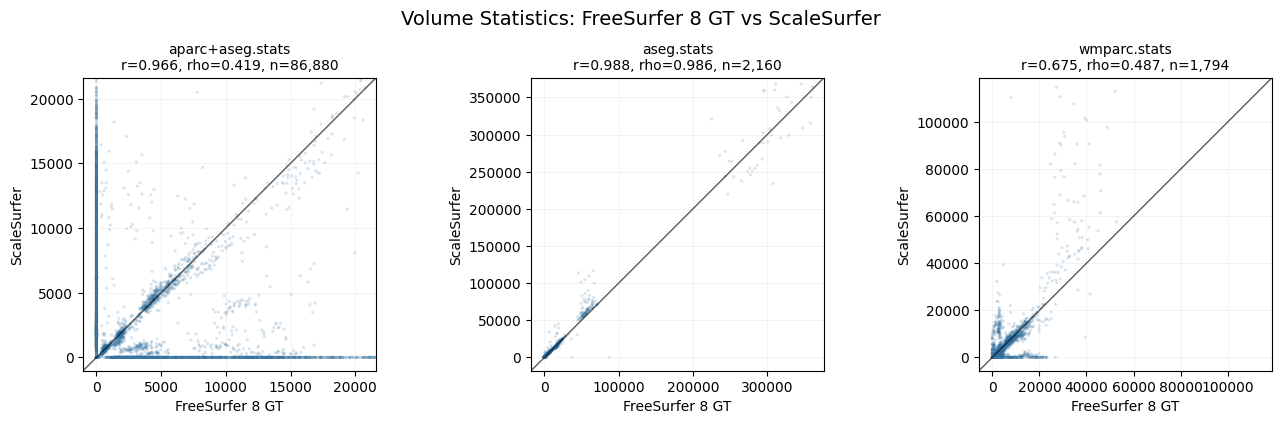

PosixPath('/home/rph/scalesurfer/docs/notebooks/02_surface/07_cortex_ode_figures/stats_volume_scatter.svg')

In [7]:
volume_corr = correlation_summary(volume_df, ["stats_file", "metric"])
display(volume_corr)

plot_scatter_facets(
    volume_df,
    group_col="stats_file",
    title="Volume Statistics: FreeSurfer 8 GT vs ScaleSurfer",
    filename="stats_volume_scatter.svg",
    color="#2f6f9f",
    point_size=5,
    alpha=0.18,
)



## 6. Surface Header Measures


,surface,metric,n,pearson_r,spearman_r,mae,rmse,bias_pred_minus_gt
0,pial,MeanThickness,96,0.209923,0.358885,0.209370,0.302326,-0.027171
1,pial,NumVert,96,0.872063,0.889511,101058.958333,101634.416931,-101058.958333
2,pial,PialSurfArea,96,0.800208,0.823087,18574.130208,19596.993826,-18358.078125
3,white,MeanThickness,96,0.209923,0.358885,0.209370,0.302326,-0.027171
4,white,NumVert,96,0.872063,0.889511,101058.958333,101634.416931,-101058.958333
5,white,WhiteSurfArea,96,0.812101,0.833817,12489.934375,13328.439635,-12190.609375


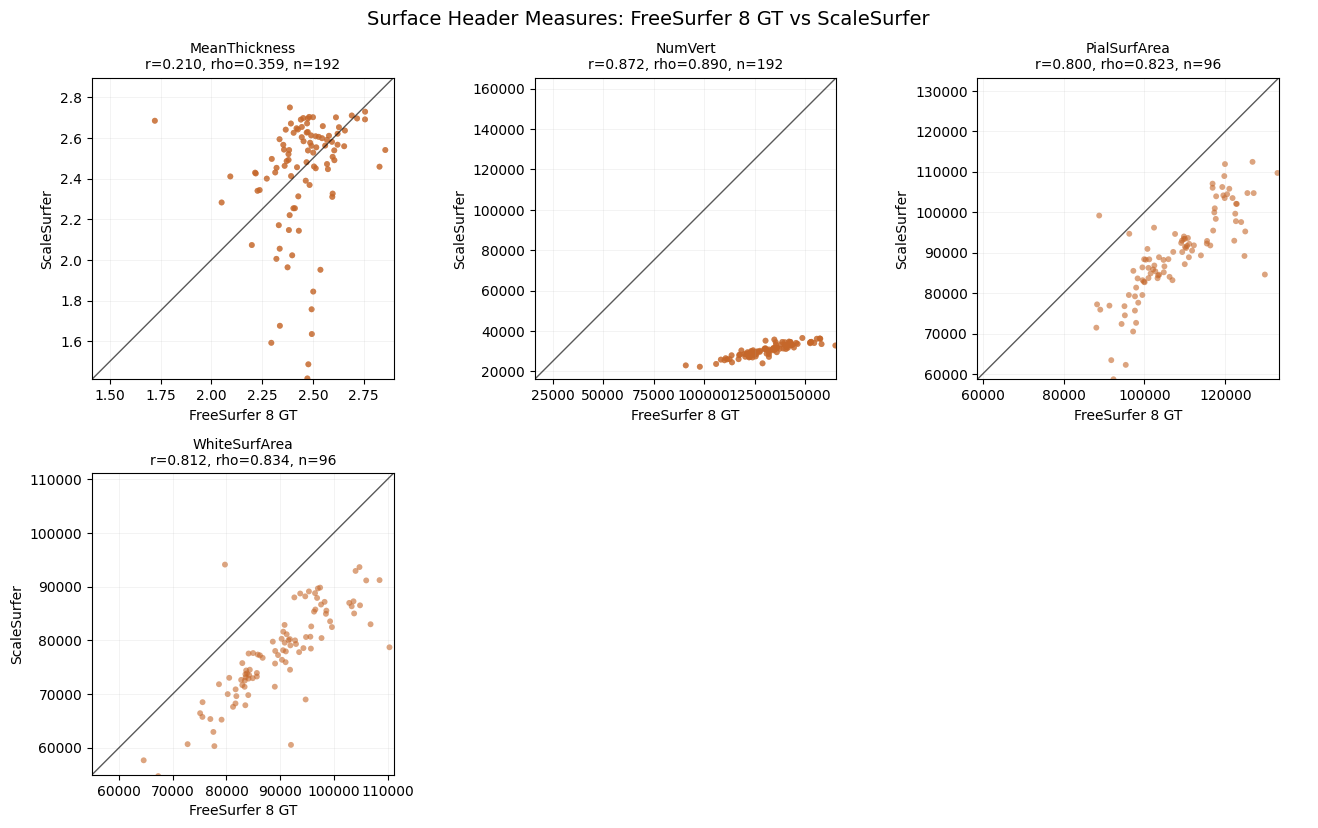

PosixPath('/home/rph/scalesurfer/docs/notebooks/02_surface/07_cortex_ode_figures/stats_surface_header_scatter.svg')

In [8]:
header_corr = correlation_summary(header_df, ["surface", "metric"])
display(header_corr)

plot_scatter_facets(
    header_df,
    group_col="metric",
    title="Surface Header Measures: FreeSurfer 8 GT vs ScaleSurfer",
    filename="stats_surface_header_scatter.svg",
    color="#c5672a",
    point_size=18,
    alpha=0.6,
)



## 7. Surface ROI Metrics


,surface,metric,n,pearson_r,spearman_r,mae,rmse,bias_pred_minus_gt
0,pial,CurvInd,472,0.032850,0.313538,3.001695,5.799408,-1.205932
1,pial,FoldInd,472,-0.002888,0.300600,119.197034,882.497180,-4.747881
2,pial,GausCurv,472,-0.009174,0.462508,0.051600,0.477542,-0.009167
3,pial,GrayVol,472,-0.044298,0.103841,3731.724576,7985.289050,-1378.838983
4,pial,MeanCurv,472,0.444332,0.379726,0.147843,0.206635,0.137441
5,pial,NumVert,472,-0.001132,0.241644,1887.841102,3679.216874,-1728.963983
6,pial,SurfArea,472,-0.029273,0.215497,1813.288136,3597.934074,-704.610169
7,pial,ThickAvg,472,0.172328,0.308609,0.966797,1.127671,0.181750
8,pial,ThickStd,472,0.321518,0.320230,0.357087,0.420279,-0.036532
9,white,CurvInd,472,0.059161,0.281590,2.454025,4.737457,-1.300636


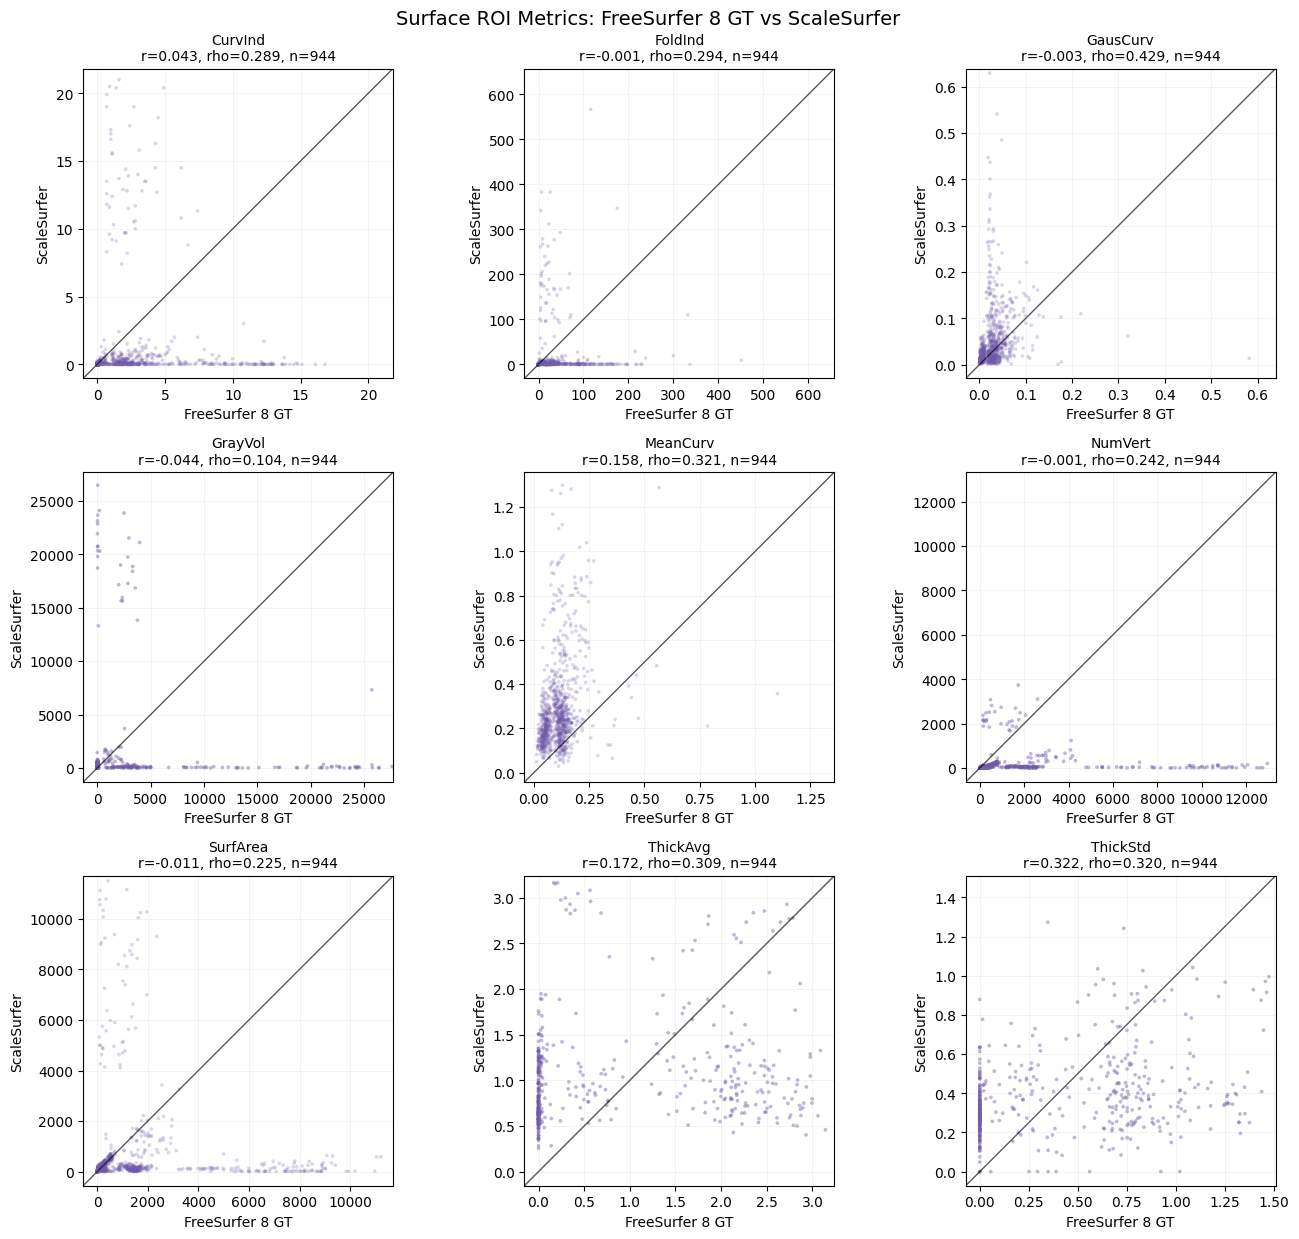

PosixPath('/home/rph/scalesurfer/docs/notebooks/02_surface/07_cortex_ode_figures/stats_surface_roi_scatter.svg')

In [9]:
roi_corr = correlation_summary(roi_df, ["surface", "metric"])
display(roi_corr)

plot_scatter_facets(
    roi_df,
    group_col="metric",
    title="Surface ROI Metrics: FreeSurfer 8 GT vs ScaleSurfer",
    filename="stats_surface_roi_scatter.svg",
    color="#6f5aa8",
    point_size=7,
    alpha=0.25,
    max_cols=3,
)



## 8. Combined Summary


In [10]:
combined_corr = pd.concat(
    [
        volume_corr.assign(scope="volume"),
        header_corr.assign(scope="surface_header"),
        roi_corr.assign(scope="surface_roi"),
    ],
    ignore_index=True,
    sort=False,
)

cols = ["scope", "stats_file", "surface", "metric", "n", "pearson_r", "spearman_r", "mae", "rmse", "bias_pred_minus_gt"]
cols = [col for col in cols if col in combined_corr.columns]
summary_table = combined_corr[cols].sort_values(["scope", "metric"]).reset_index(drop=True)
summary_table.to_csv(SUMMARY_CSV, index=False)
display(summary_table)

print(f"Saved metric summary: {SUMMARY_CSV}")
print("Saved figures:")
for path in sorted(FIG_DIR.glob("stats_*_scatter.svg")):
    print(path)



,scope,stats_file,surface,metric,n,pearson_r,spearman_r,mae,rmse,bias_pred_minus_gt
0,surface_header,NaN,pial,MeanThickness,96,0.209923,0.358885,0.209370,0.302326,-0.027171
1,surface_header,NaN,white,MeanThickness,96,0.209923,0.358885,0.209370,0.302326,-0.027171
2,surface_header,NaN,pial,NumVert,96,0.872063,0.889511,101058.958333,101634.416931,-101058.958333
3,surface_header,NaN,white,NumVert,96,0.872063,0.889511,101058.958333,101634.416931,-101058.958333
4,surface_header,NaN,pial,PialSurfArea,96,0.800208,0.823087,18574.130208,19596.993826,-18358.078125
5,surface_header,NaN,white,WhiteSurfArea,96,0.812101,0.833817,12489.934375,13328.439635,-12190.609375
6,surface_roi,NaN,pial,CurvInd,472,0.032850,0.313538,3.001695,5.799408,-1.205932
7,surface_roi,NaN,white,CurvInd,472,0.059161,0.281590,2.454025,4.737457,-1.300636
8,surface_roi,NaN,pial,FoldInd,472,-0.002888,0.300600,119.197034,882.497180,-4.747881
9,surface_roi,NaN,white,FoldInd,472,0.013564,0.298223,267.463983,5165.399910,234.480932


Saved metric summary: /home/rph/scalesurfer/docs/notebooks/02_surface/07_cortex_ode_figures/metric_summary.csv
Saved figures:
/home/rph/scalesurfer/docs/notebooks/02_surface/07_cortex_ode_figures/stats_surface_header_scatter.svg
/home/rph/scalesurfer/docs/notebooks/02_surface/07_cortex_ode_figures/stats_surface_roi_scatter.svg
/home/rph/scalesurfer/docs/notebooks/02_surface/07_cortex_ode_figures/stats_volume_scatter.svg
